Setup & installs

In [1]:
!pip install monai kaggle -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.9 MB/s eta 0:00:00


Download dataset


In [9]:
import os

os.makedirs('/content/lung_data', exist_ok=True)
os.chdir('/content/lung_data')

!wget --tries=3 --timeout=60 http://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip
!ls -la

--2026-09-12 10:02:22--  http://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip
Resolving openi.nlm.nih.gov (openi.nlm.nih.gov)... 130.14.65.157, 2607:f220:41e:7065::157
Connecting to openi.nlm.nih.gov (openi.nlm.nih.gov)|130.14.65.157|:80... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip [following]
--2026-09-12 10:02:23--  https://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip
Connecting to openi.nlm.nih.gov (openi.nlm.nih.gov)|130.14.65.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 616853875 (588M) [application/zip]
Saving to: ‘NLM-MontgomeryCXRSet.zip’

NLM-MontgomeryCXRSe 100%[===================>] 588.28M  1.99MB/s    in 5m 1s   

2026-09-12 10:07:23 (1.96 MB/s) - ‘NLM-MontgomeryCXRSet.zip’ saved [616853875/616853875]

total 602412
drwxr-xr-x 2 root root      4096 Sep 12 10:02 .
drwxr-xr-x 1 root root      4096 Sep 12 09:

In [10]:
!unzip -q NLM-MontgomeryCXRSet.zip
!find /content/lung_data -maxdepth 4 -type d

/content/lung_data
/content/lung_data/MontgomerySet
/content/lung_data/MontgomerySet/CXR_png
/content/lung_data/MontgomerySet/ManualMask
/content/lung_data/MontgomerySet/ManualMask/rightMask
/content/lung_data/MontgomerySet/ManualMask/leftMask
/content/lung_data/MontgomerySet/ClinicalReadings
/content/lung_data/__MACOSX
/content/lung_data/__MACOSX/MontgomerySet
/content/lung_data/__MACOSX/MontgomerySet/CXR_png
/content/lung_data/__MACOSX/MontgomerySet/ManualMask
/content/lung_data/__MACOSX/MontgomerySet/ManualMask/leftMask


Build image-mask pairs (combine left+right masks)

In [11]:
import glob, os
import numpy as np
from PIL import Image

img_dir = '/content/lung_data/MontgomerySet/CXR_png'
left_dir = '/content/lung_data/MontgomerySet/ManualMask/leftMask'
right_dir = '/content/lung_data/MontgomerySet/ManualMask/rightMask'

images = sorted(glob.glob(os.path.join(img_dir, '*.png')))
print(f"Total Montgomery images: {len(images)}")

# Create combined masks folder
combined_dir = '/content/lung_data/combined_masks'
os.makedirs(combined_dir, exist_ok=True)

pairs = []
for img_path in images:
    fname = os.path.basename(img_path)
    left_path = os.path.join(left_dir, fname)
    right_path = os.path.join(right_dir, fname)

    if os.path.exists(left_path) and os.path.exists(right_path):
        left = np.array(Image.open(left_path).convert('L'))
        right = np.array(Image.open(right_path).convert('L'))
        combined = np.maximum(left, right)  # merge both lungs

        out_path = os.path.join(combined_dir, fname)
        Image.fromarray(combined).save(out_path)
        pairs.append((img_path, out_path))

print(f"Matched image-mask pairs: {len(pairs)}")
print(pairs[0])

Total Montgomery images: 138
Matched image-mask pairs: 138
('/content/lung_data/MontgomerySet/CXR_png/MCUCXR_0001_0.png', '/content/lung_data/combined_masks/MCUCXR_0001_0.png')


Dataset Class

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

IMG_SIZE = 256

class LungSegDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.pairs = pairs
        self.augment = augment
        self.img_tf = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
        ])
        self.mask_tf = T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        image = Image.open(img_path).convert('L')
        mask  = Image.open(mask_path).convert('L')

        image = self.img_tf(image)
        mask  = self.mask_tf(mask)
        mask  = (mask > 0.5).float()  # binarize

        return image, mask

Train/val split & dataloaders

In [13]:
import random
random.seed(42)
random.shuffle(pairs)

split = int(0.85 * len(pairs))
train_pairs = pairs[:split]
val_pairs   = pairs[split:]

train_ds = LungSegDataset(train_pairs)
val_ds   = LungSegDataset(val_pairs)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 117 | Val: 21


U-Net model (MONAI)

In [14]:
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

loss_fn = DiceLoss(sigmoid=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
dice_metric = DiceMetric(include_background=True, reduction="mean")

print(model)

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (adn): ADN(
            (N): InstanceNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (adn): ADN(
            (N): InstanceNorm2d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential(
            (unit

Training Loop

In [15]:
import time

EPOCHS = 40
best_dice = 0.0
train_losses, val_dices = [], []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    start = time.time()

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    dice_metric.reset()
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = torch.sigmoid(model(images))
            preds = (outputs > 0.5).float()
            dice_metric(y_pred=preds, y=masks)

    val_dice = dice_metric.aggregate().item()
    val_dices.append(val_dice)

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_lung_unet.pth")

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Dice: {val_dice:.4f} | Time: {time.time()-start:.1f}s")

print(f"\nBest Val Dice: {best_dice:.4f}")

Epoch 1/40 | Train Loss: 0.6180 | Val Dice: 0.3888 | Time: 64.8s
Epoch 2/40 | Train Loss: 0.5815 | Val Dice: 0.4215 | Time: 64.7s
Epoch 3/40 | Train Loss: 0.5581 | Val Dice: 0.4713 | Time: 59.0s
Epoch 4/40 | Train Loss: 0.5357 | Val Dice: 0.5172 | Time: 59.1s
Epoch 5/40 | Train Loss: 0.5172 | Val Dice: 0.5518 | Time: 67.9s
Epoch 6/40 | Train Loss: 0.5037 | Val Dice: 0.5868 | Time: 59.1s
Epoch 7/40 | Train Loss: 0.4942 | Val Dice: 0.6255 | Time: 59.1s
Epoch 8/40 | Train Loss: 0.4872 | Val Dice: 0.6609 | Time: 59.3s
Epoch 9/40 | Train Loss: 0.4833 | Val Dice: 0.6956 | Time: 58.1s
Epoch 10/40 | Train Loss: 0.4799 | Val Dice: 0.7278 | Time: 58.6s
Epoch 11/40 | Train Loss: 0.4763 | Val Dice: 0.7528 | Time: 59.1s
Epoch 12/40 | Train Loss: 0.4751 | Val Dice: 0.7807 | Time: 58.7s
Epoch 13/40 | Train Loss: 0.4729 | Val Dice: 0.7942 | Time: 58.0s
Epoch 14/40 | Train Loss: 0.4693 | Val Dice: 0.8105 | Time: 58.3s
Epoch 15/40 | Train Loss: 0.4662 | Val Dice: 0.8233 | Time: 64.3s
Epoch 16/40 | Train

Plot training curves

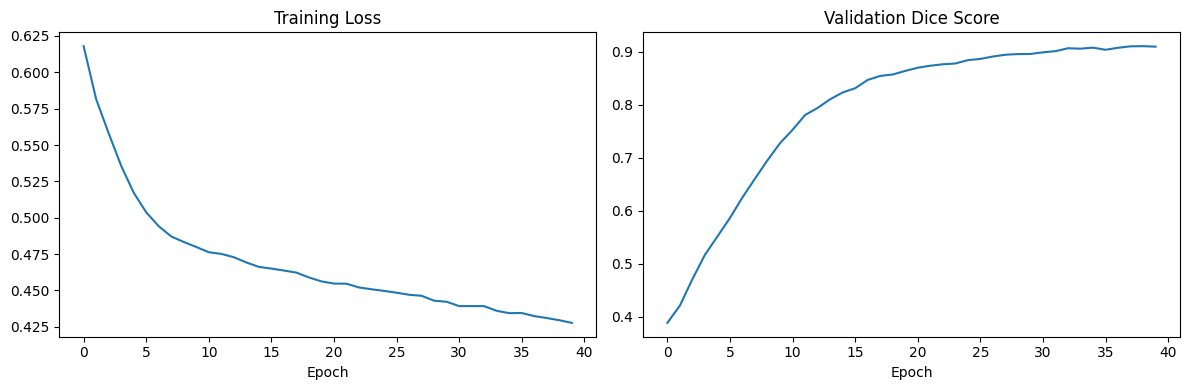

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_losses)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")

ax[1].plot(val_dices)
ax[1].set_title("Validation Dice Score")
ax[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

Visualize Predictions

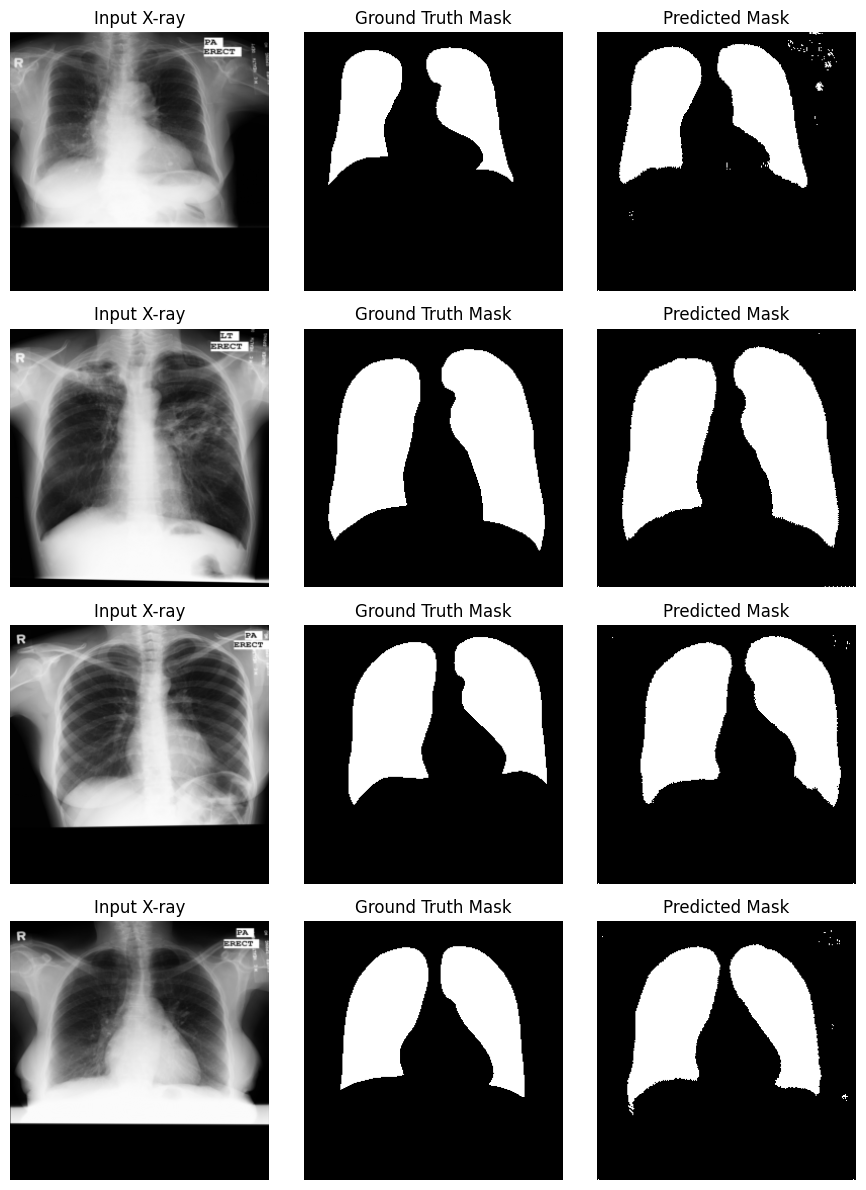

In [17]:
model.load_state_dict(torch.load("best_lung_unet.pth"))
model.eval()

fig, axes = plt.subplots(4, 3, figsize=(9, 12))

with torch.no_grad():
    for i in range(4):
        image, mask = val_ds[i]
        pred = torch.sigmoid(model(image.unsqueeze(0).to(device)))
        pred = (pred > 0.5).float().cpu().squeeze()

        axes[i, 0].imshow(image.squeeze(), cmap='gray')
        axes[i, 0].set_title("Input X-ray")
        axes[i, 1].imshow(mask.squeeze(), cmap='gray')
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 2].imshow(pred, cmap='gray')
        axes[i, 2].set_title("Predicted Mask")

        for ax in axes[i]:
            ax.axis('off')

plt.tight_layout()
plt.savefig("predictions_sample.png", dpi=150)
plt.show()

Final metrics summary

In [18]:
model.eval()
dice_metric.reset()

from monai.metrics import MeanIoU
iou_metric = MeanIoU(include_background=True, reduction="mean")

with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = torch.sigmoid(model(images))
        preds = (outputs > 0.5).float()
        dice_metric(y_pred=preds, y=masks)
        iou_metric(y_pred=preds, y=masks)

final_dice = dice_metric.aggregate().item()
final_iou = iou_metric.aggregate().item()

print(f"Final Validation Dice Score: {final_dice:.4f}")
print(f"Final Validation IoU: {final_iou:.4f}")

Final Validation Dice Score: 0.9106
Final Validation IoU: 0.8425


In [20]:
from google.colab import files
import shutil, os

os.makedirs('/content/download_bundle', exist_ok=True)

shutil.copy('/content/lung_data/training_curves.png', '/content/download_bundle/')
shutil.copy('/content/lung_data/predictions_sample.png', '/content/download_bundle/')
shutil.copy('/content/lung_data/best_lung_unet.pth', '/content/download_bundle/')

shutil.make_archive('/content/lung_seg_bundle', 'zip', '/content/download_bundle')

files.download('/content/lung_seg_bundle.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>